# 2-1 기계가 선을 긋는다면?

본 노트북은 본문 2-1 절(퍼셉트론의 구조와 동작 원리)을 다룬다. 2-1 절은 본문에 대응되는 실행 코드 예제(`# 코드 2-M`)가 없으므로, 본 노트북은 [그림 2-3] 결정 경계 예시와 [그림 2-4] 활성화 함수 비교를 재현하는 보조 시각화 셀(`# 참고`)로만 구성한다.

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

## 라이브러리 import 와 시드 고정

본 절에는 본문 코드가 없으므로, 보조 셀의 시각화에 필요한 라이브러리를 먼저 import 하고 시드를 고정한다.

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
import random

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 결정 경계 예시 ([그림 2-3] 대응)

본문 [그림 2-3] 은 좌표 평면 위 두 부류의 데이터를 한 직선이 나누는 모습을 보여 준다. 임의의 2D 샘플 8개를 두 부류로 두고, $x_2 = -x_1 + 1.5$ 직선을 결정 경계로 그려 재현한다.

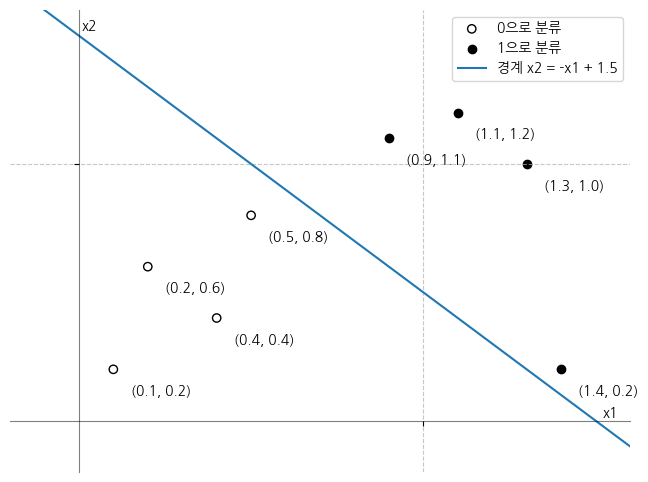

In [5]:
# 참고 - [그림 2-3] 결정 경계 예시 시각화
# 두 부류의 2D 샘플 (왼쪽 아래는 0, 오른쪽 위는 1)
x1_list = [0.1, 0.2, 0.4, 0.5, 0.9, 1.1, 1.3, 1.4]
x2_list = [0.2, 0.6, 0.4, 0.8, 1.1, 1.2, 1.0, 0.2]
y_list = [0, 0, 0, 0, 1, 1, 1, 1]

# 결정 경계 직선 x2 = -x1 + 1.5
viz.plot_decision_boundary(
    sample=(x1_list, x2_list, y_list),
    boundary_fn=lambda x: -x + 1.5,    
    baseline_name='경계 x2 = -x1 + 1.5',
    x_lim=(-0.2, 1.6), y_lim=(-0.2, 1.6),
    x_label='x1', y_label='x2',
)

## 활성화 함수 비교 ([그림 2-4] 대응)

본문 [그림 2-4] 는 계단 함수와 시그모이드 함수를 함께 보여 준다. 두 함수를 정의해 같은 입력 범위에서 비교한다.

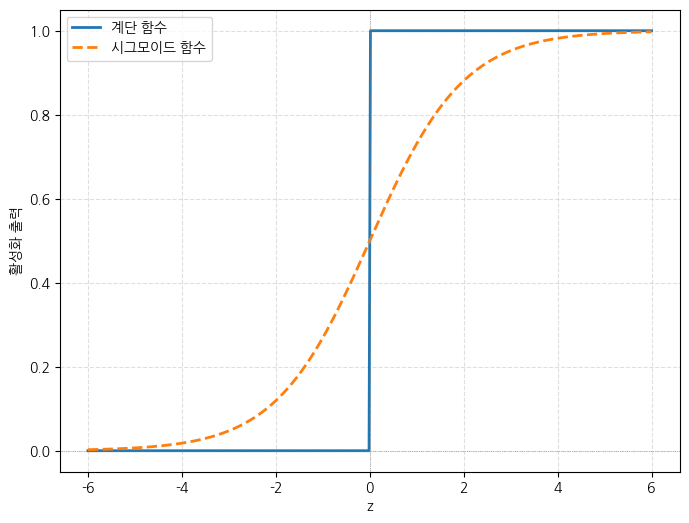

In [6]:
# 참고 - 계단 함수와 시그모이드 함수의 비교 ([그림 2-4] 대응)
viz.plot_activation_compare(
    {'계단 함수': lambda z: (z >= 0).float(),
     '시그모이드 함수': torch.sigmoid},
    x_range=(-6, 6),
    x_label='z', y_label='활성화 출력',
)

시그모이드 함수는 모든 점에서 매끄러워 미분이 가능하므로, 경사하강법에서 기울기를 구할 수 있다. 다음 절(2-2)에서는 이 시그모이드 함수를 활성화 함수로 사용하는 퍼셉트론 모델을 직접 구현한다.